In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NAV

In [2]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv", parse_dates=["date"])
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


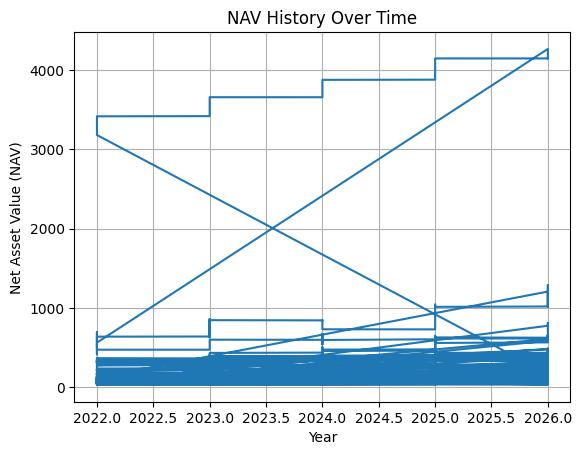

In [4]:
plt.plot(nav['date'].dt.year, nav['nav'])
plt.xlabel('Year')
plt.ylabel('Net Asset Value (NAV)')
plt.title('NAV History Over Time')
plt.grid()
plt.show()

In [5]:
plt.plot(nav['year'], nav['nav'])
plt.xlabel('Year')
plt.ylabel('Net Asset Value (NAV)')
plt.axvspan(2022, 2022.99, alpha=0.2, label='COVID',color='red')
plt.axvspan(2023, 2023.99, alpha=0.2, label='2023 Rally',color='green')
plt.axvspan(2024, 2024.99, alpha=0.2, label='2024 Correction',color='blue')
plt.title('NAV History Over Time')
plt.grid()
plt.legend()
plt.show()

KeyError: 'year'

# AUM

In [ ]:
aum = pd.read_csv('../data/processed/clean_aum_by_fund_house.csv',parse_dates=["date"])
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [ ]:
aum.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[ns]
 1   fund_house      90 non-null     object        
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 3.6+ KB


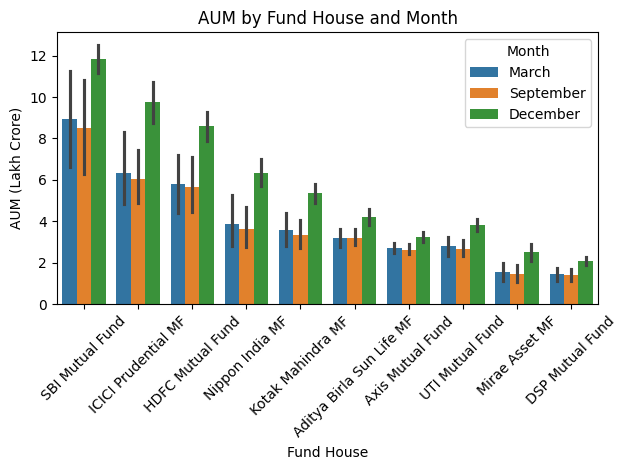

In [ ]:
sns.barplot(data=aum,x='fund_house',y='aum_lakh_crore',hue=aum['date'].dt.month_name())
plt.xlabel('Fund House')
plt.ylabel('AUM (Lakh Crore)')
plt.title('AUM by Fund House and Month')
plt.xticks(rotation=45)
plt.legend(title='Month')
plt.tight_layout()
plt.show()

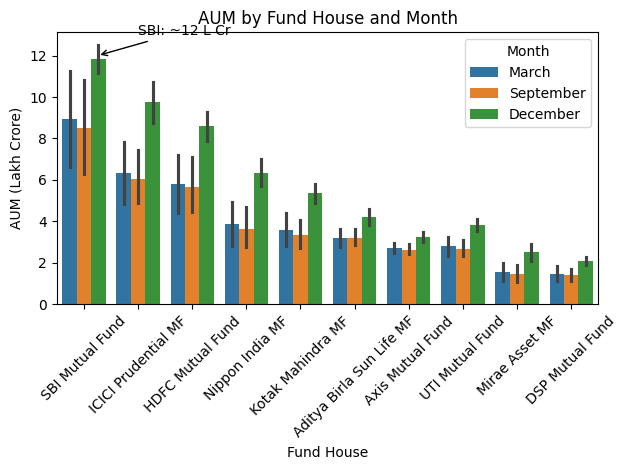

In [ ]:
sns.barplot(data=aum,x='fund_house',y='aum_lakh_crore',hue=aum['date'].dt.month_name())
plt.xlabel('Fund House')
plt.ylabel('AUM (Lakh Crore)')
plt.title('AUM by Fund House and Month')
plt.annotate('SBI: ~12 L Cr',xy=(0.25, 12),xytext=(1, 13),arrowprops=dict(arrowstyle='->'))
plt.xticks(rotation=45)
plt.legend(title='Month')
plt.tight_layout()
plt.show()

# SIP Inflow

In [ ]:
sip = pd.read_csv('../data/processed/clean_monthly_sip_inflowS.csv',parse_dates=["month"])
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,31.456944
1,2022-02-01,11438,4.93,8.20,4.85,31.456944
2,2022-03-01,12328,5.09,10.50,5.01,31.456944
3,2022-04-01,11863,5.48,9.52,5.12,31.456944
4,2022-05-01,12286,5.55,8.10,5.15,31.456944


In [ ]:
sip['year'] = sip['month'].dt.year
sip['month'] = sip['month'].dt.month_name()

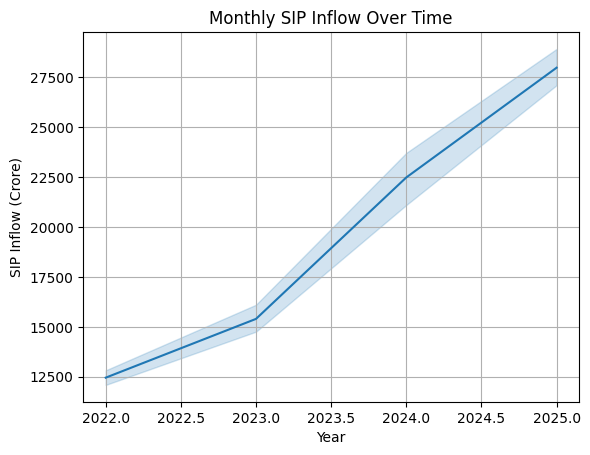

In [ ]:
sns.lineplot(data=sip, x='year', y='sip_inflow_crore')
plt.xlabel('Year')
plt.ylabel('SIP Inflow (Crore)')
plt.title('Monthly SIP Inflow Over Time')
plt.grid()
plt.show()

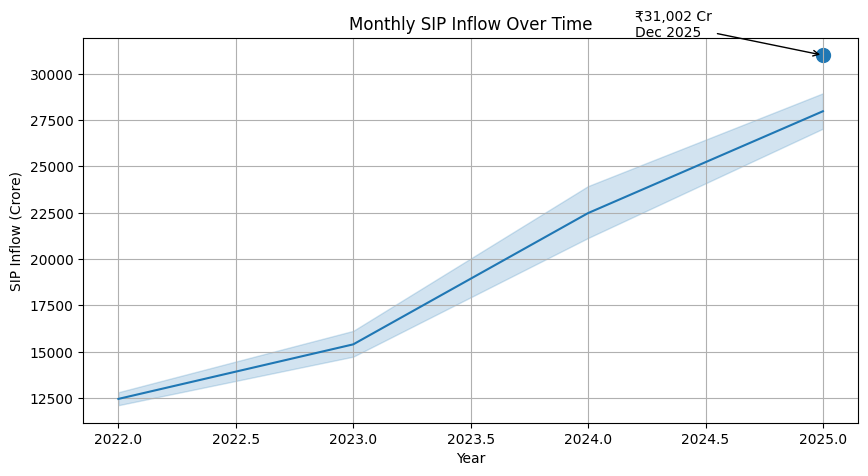

In [ ]:
milestone = sip[(sip['year'] == 2025) & (sip['month'] == 'December')]

plt.figure(figsize=(10,5))
sns.lineplot(data=sip, x='year', y='sip_inflow_crore')
plt.scatter(milestone['year'],milestone['sip_inflow_crore'],s=100)
plt.annotate('₹31,002 Cr\nDec 2025',xy=(2025, 31002),xytext=(2024.2, 32000),arrowprops=dict(arrowstyle='->'))
plt.xlabel('Year')
plt.ylabel('SIP Inflow (Crore)')
plt.title('Monthly SIP Inflow Over Time')
plt.grid()
plt.show()

# Category inflow

In [ ]:
cat = pd.read_csv('../data/processed/clean_category_inflows.csv')

cat['month'] = cat['month'].astype('datetime64[ns]')
cat['month'] = cat['month'].dt.month_name()

cat.head()

,month,category,net_inflow_crore
0,January,Large Cap,2413.0
1,January,Mid Cap,3897.0
2,January,Small Cap,3533.0
3,January,Flexi Cap,4947.0
4,January,Large & Mid Cap,4214.0


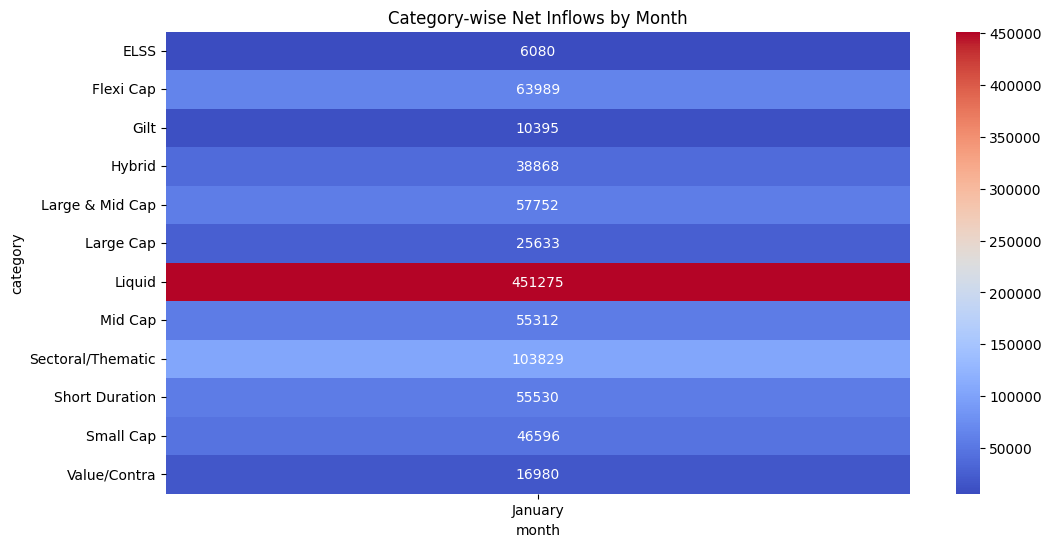

In [ ]:
pivot = cat.pivot_table(index='category', columns='month', values='net_inflow_crore',
                        aggfunc='sum')

plt.figure(figsize=(12,6))

sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt='.0f')
plt.title('Category-wise Net Inflows by Month')
plt.show()

# Investor

In [ ]:
invest = pd.read_csv('../data/processed/clean_investor_transactions.csv', parse_dates=["transaction_date"])
invest.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [ ]:
invest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  object        
 1   transaction_date    32778 non-null  datetime64[ns]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  object        
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  object        
 6   city                32778 non-null  object        
 7   city_tier           32778 non-null  object        
 8   age_group           32778 non-null  object        
 9   gender              32778 non-null  object        
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  object        
 12  kyc_status          32778 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), ob

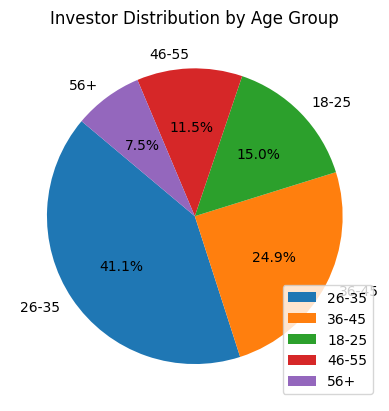

In [ ]:
plt.pie(invest['age_group'].value_counts(), labels=invest['age_group'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.title('Investor Distribution by Age Group')
plt.legend()
plt.show()

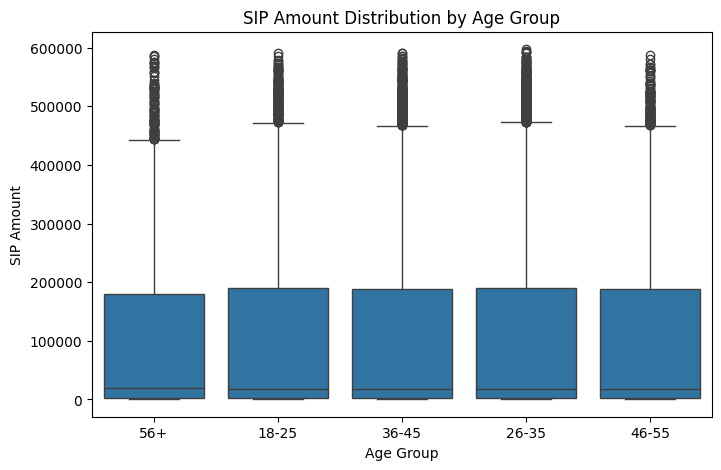

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=invest, x='age_group', y='amount_inr')
plt.title('SIP Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('SIP Amount')
plt.show()

# geographic distribution 

In [13]:
invest = pd.read_csv('../data/processed/clean_investor_transactions.csv')
invest.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


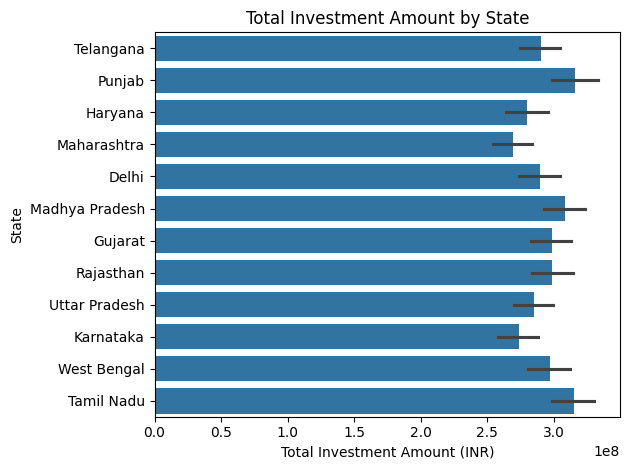

In [ ]:
sns.barplot(data=invest,y='state',x='amount_inr',estimator=sum)
plt.xlabel('Total Investment Amount (INR)')
plt.ylabel('State')
plt.title('Total Investment Amount by State')
plt.tight_layout()
plt.show()

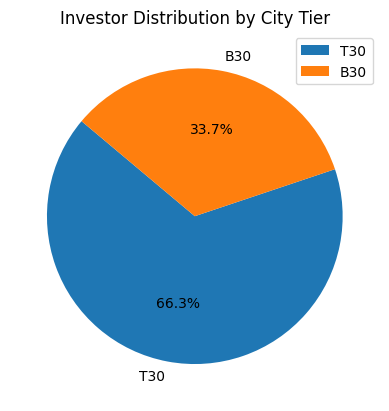

In [15]:
plt.pie(invest['city_tier'].value_counts(), labels=invest['city_tier'].value_counts().index, autopct='%1.1f%%', startangle=140)
plt.title('Investor Distribution by City Tier')
plt.legend()
plt.show()

# industry folio

In [46]:
folio = pd.read_csv('../data/processed/clean_industry_folio_count.csv')
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore,year
0,1,13.26,9.28,1.86,0.80,1.33,2022
1,4,13.91,9.74,1.95,0.83,1.39,2022
2,7,13.85,9.69,1.94,0.83,1.38,2022
3,10,14.12,9.88,1.98,0.85,1.41,2022
4,1,14.81,10.37,2.07,0.89,1.48,2023


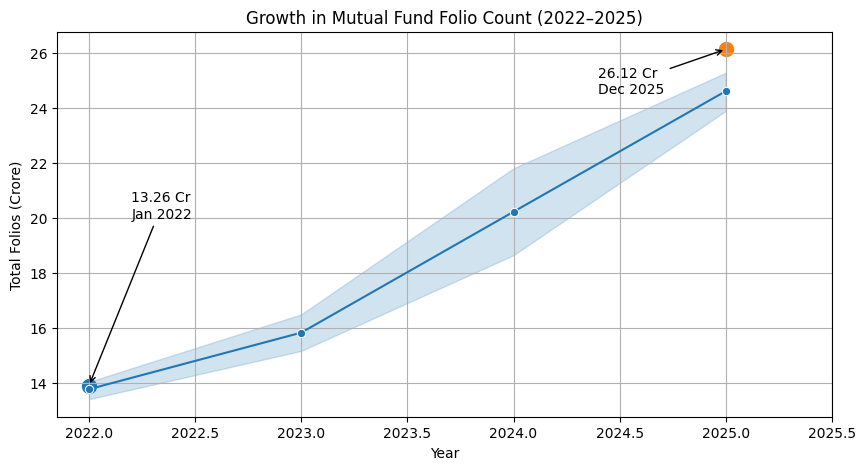

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(data=folio, x='year', y='total_folios_crore', marker='o')
plt.scatter(folio['year'].iloc[1],folio['total_folios_crore'].iloc[1],s=100)
plt.annotate('13.26 Cr\nJan 2022',xy=(folio['year'].iloc[1], folio['total_folios_crore'].iloc[1]),
             xytext=(2022.2, 20),arrowprops=dict(arrowstyle='->'))
plt.scatter(folio['year'].iloc[-1],folio['total_folios_crore'].iloc[-1],s=100)
plt.annotate('26.12 Cr\nDec 2025',xy=(folio['year'].iloc[-1], folio['total_folios_crore'].iloc[-1]),
             xytext=(2024.4, 24.5),arrowprops=dict(arrowstyle='->'))
plt.title('Growth in Mutual Fund Folio Count (2022–2025)')
plt.xlabel('Year')
plt.ylabel('Total Folios (Crore)')
plt.grid()
plt.show()

# nav

In [71]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv", parse_dates=["date"])
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [72]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


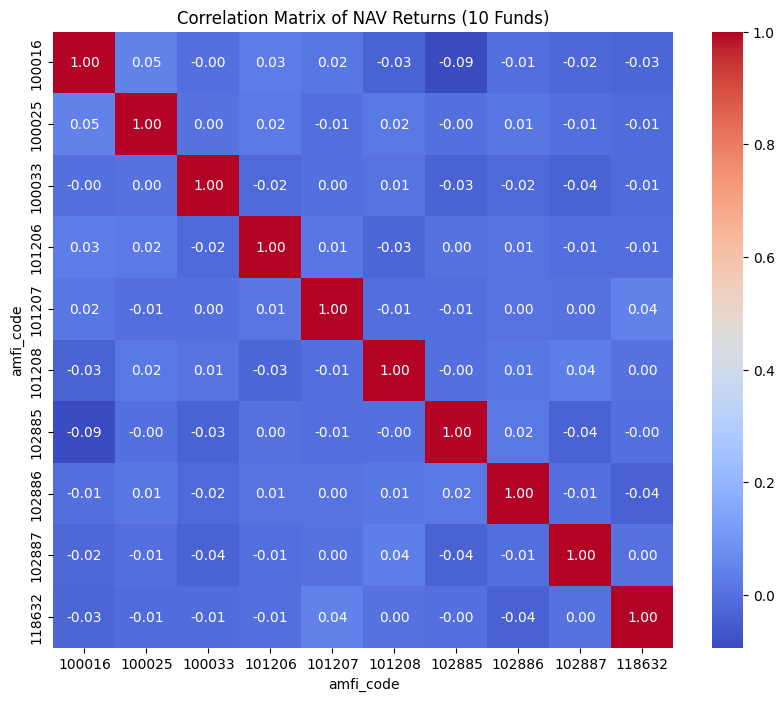

In [ ]:
selected_funds = nav['amfi_code'].unique()[:10]

nav_10 = nav[nav['amfi_code'].isin(selected_funds)].copy()

nav_pivot = nav_10.pivot(index='date',columns='amfi_code',values='nav')
returns = nav_pivot.pct_change()
plt.figure(figsize=(10,8))
sns.heatmap(returns.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix of NAV Returns (10 Funds)')
plt.show()

# portfolio

In [91]:
port = pd.read_csv('../data/processed/clean_portfolio_holdings.csv')
port.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [94]:
df = port.groupby('sector')['weight_pct'].sum().sort_values(ascending=False).head(10)
df

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
Name: weight_pct, dtype: float64

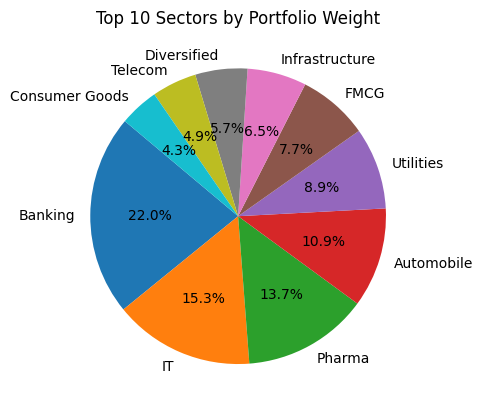

In [100]:
plt.pie(df, labels=df.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Sectors by Portfolio Weight') 
plt.show()